# Laboratorio 2: Question Answering y RAG
## *Procesamiento del Lenguaje Natural con Transformers*

> **Universidad de El Salvador**  
> Facultad de Ingeniería y Arquitectura | Escuela de Ingeniería de Sistemas Informáticos  
> *Curso de Especialización*

---

### Objetivos Generales

Al finalizar esta práctica, el estudiante será capaz de:
- Comprender el funcionamiento de los sistemas de *Question Answering* (QA).
- Diferenciar los principales tipos de QA.
- Utilizar modelos preentrenados de Hugging Face.
- Implementar sistemas de preguntas y respuestas en español.
- Interpretar el *score* de confianza y las respuestas candidatas.
- Analizar las limitaciones de los modelos extractivos.

### Requisitos de Ejecución

* **Entorno:** Google Colab, Jupyter o equivalente.
* **Lenguaje:** Python 3.10 o superior.
* **Librerías:** `transformers`, `torch` (PyTorch).

## 1. Fundamentos de Question Answering
> El **Question Answering (QA)** es una tarea fundamental del Procesamiento del Lenguaje Natural (NLP) cuyo objetivo consiste en responder automáticamente preguntas formuladas en lenguaje natural utilizando la información contenida en un texto.

### Estructura del Modelo

Un sistema de QA extractivo funciona como una función que mapea entradas específicas a un conjunto de predicciones:

**Entradas (Inputs):**
1. **Contexto:** El documento o párrafo de referencia.
2. **Pregunta:** La consulta formulada por el usuario.

**Salidas (Outputs):**
```python
{
  "respuesta": "cadena de texto extraída",
  "confianza": 0.98,  # Score de probabilidad del modelo
  "posicion": (inicio, fin) # Índices dentro del texto original
}

### Objetivos de aprendizaje

```markdown
🛠️ 1 Preparacion del Entorno
    └── Instalar librería Transformers
🧩 2 Carga de Componentes
    ├── Cargar modelos preentrenados
    └── Utilizar Tokenizers
🚀 3 Implementacion Base
    ├── Construir un Pipeline de QA
    └── Responder preguntas en español
📊 4 Analisis y Ajustes
    ├── Analizar la confianza (score) de las respuestas
    ├── Trabajar con múltiples respuestas candidatas (`top_k`)
    └── Detectar preguntas sin respuesta (unanswerable)
```

### Tipos de Question Answering

Existen cuatro categorías principales que definen el comportamiento y alcance de estos sistemas:

| Categoría | Descripción | Característica clave / Ejemplo |
| :--- | :--- | :--- |
| **QA Extractivo** | Extrae literalmente un fragmento del contexto proporcionado. | *Ej:* Extraer "una estrella" del texto "El Sol es una estrella". |
| **QA Abstractivo** | Genera una respuesta nueva utilizando un modelo de lenguaje. | Parafrasea y sintetiza información en sus propias palabras. |
| **Dominio Abierto** | (*Open Domain*) Puede responder preguntas sobre cualquier tema. | Utiliza corpus masivos de información general. |
| **Dominio Cerrado** | (*Closed Domain*) Especializado en un dominio específico. | Restringido a un área (ej. documentos legales o médicos). |

### Arquitectura Transformer

Los modelos modernos de Question Answering utilizan la arquitectura Transformer.

Componentes principales

- Embeddings
- Positional Encoding
- Multi-Head Attention
- Feed Forward Network
- Encoder
- Decoder

Para QA extractivo normalmente solo se utiliza el Encoder.

### Modelos QA en español

El notebook utiliza modelos BERT entrenados para español y ajustados para QA extractivo. Los identificadores realmente cargados en los experimentos son:

|Nombre descriptivo coherente|Identificador de Hugging Face|
|---|---|
|BETO-SQuAD2 (mrm8488)|`mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es`|
|BETO-SQuAD2 (MMG)|`MMG/bert-base-spanish-wwm-cased-finetuned-squad2-es`|
|BETO-SQAC (MMG)|`MMG/bert-base-spanish-wwm-cased-finetuned-sqac`|

Los nombres descriptivos se derivan de la arquitectura y del corpus indicado por cada repositorio. En particular, el modelo base de `mrm8488` es BERT/BETO, no RoBERTa-BNE.


### Score de Confianza y parámetro `top_k`

**¿Qué es el Score?**

El score representa la probabilidad conjunta de que el modelo haya identificado correctamente el token de inicio y el token de fin de la respuesta:

$$\text{score} = P(\text{inicio} = i) \times P(\text{fin} = j)$$

---
> ⚠️ **Falsa confianza:** el score puede ser alto aunque la respuesta sea incorrecta. Siempre validar contra el contexto original.


**¿Qué hace el parámetro `top_k`?**

Permite recuperar las `k` respuestas candidatas más probables en lugar de solo la mejor.

```python
# top_k=1  →  Solo la mejor respuesta
# top_k=3  →  Las 3 respuestas más probables
responder_pregunta(contexto, pregunta, top_k=3)
```

Utilidades de `top_k`:
- Evaluar la confianza relativa entre respuestas alternativas.
- Detectar ambigüedad o información contradictoria en el texto.
- Auditar el comportamiento del modelo en casos límite.

---

**Limitaciones del modelo extractivo**

| Limitación | Descripción |
| :--- | :--- |
| Solo extrae texto | No puede inferir ni razonar; la respuesta debe estar *literalmente* en el contexto. |
| Límite de tokens | Acepta un máximo de **512 tokens**; textos más largos se truncan. |
| Sin memoria | Cada pregunta se procesa de forma independiente, sin historial. |
| Falsa confianza | Puede devolver score alto aunque la respuesta sea incorrecta. |
| Idioma | El rendimiento depende del idioma y corpus de entrenamiento del modelo. |

In [72]:
# ----------------------------------------------------
# IMPORTACIÓN DE LIBRERÍAS
# ----------------------------------------------------

import torch
import numpy as np
import pandas as pd
from transformers import pipeline, AutoTokenizer, AutoModelForQuestionAnswering
from huggingface_hub import list_models
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

print("PyTorch:", torch.__version__)

# Verificar GPU
if torch.cuda.is_available():
    print("GPU disponible:", torch.cuda.get_device_name(0))
else:
    print("GPU no disponible, se utilizará CPU.")

# Cargar modelo y tokenizer
model_name = "mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

# Mover a GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f" Modelo cargado en: {device}")


PyTorch: 2.13.0+cpu
GPU no disponible, se utilizará CPU.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18661.77it/s]
[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Modelo cargado en: cpu


In [73]:
# ---------------------------------------------------
# responder_pregunta(): 
# Implementa un pipeline de QA básico. Realiza la tokenización de la pregunta y el contexto, 
# luego obtiene los logits de inicio y fin, calcula las probabilidades y genera
# candidatos de respuesta. Finalmente, ordena las respuestas por score y devuelve las mejores.
# ---------------------------------------------------

def responder_pregunta(contexto, pregunta, top_k=3):
    """
    Responde una pregunta utilizando un modelo de
    Question Answering (sin usar el objeto pipeline).

    Parámetros
    ----------
    contexto : str
        Texto donde buscar la respuesta.

    pregunta : str
        Pregunta formulada por el usuario.

    top_k : int
        Número máximo de respuestas a devolver.

    Retorna
    -------
    list
        Lista de respuestas ordenadas por confianza.
    """
    # Tokenizar el input
    inputs = tokenizer(
        pregunta,
        contexto,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Mover las entradas al dispositivo definido al cargar el modelo
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Obtener predicciones
    with torch.no_grad():
        outputs = model(**inputs)

    start_logits = outputs.start_logits.cpu().squeeze()
    end_logits = outputs.end_logits.cpu().squeeze()

    # Convertir los logits en probabilidades
    start_probs = torch.softmax(start_logits, dim=-1)
    end_probs = torch.softmax(end_logits, dim=-1)

    all_answers = []
    # Obtener candidatos de inicio y fin
    # Se consideran candidatos adicionales para formar suficientes spans válidos.
    num_spans_to_consider = min(len(start_probs), 2 * top_k) # Número acotado de posiciones candidatas
    top_k_start_scores, top_k_start_indices = torch.topk(start_probs, num_spans_to_consider)
    top_k_end_scores, top_k_end_indices = torch.topk(end_probs, num_spans_to_consider)

    # Combinar posiciones candidatas de inicio y fin
    for s_score, s_idx in zip(top_k_start_scores, top_k_start_indices):
        for e_score, e_idx in zip(top_k_end_scores, top_k_end_indices):
            if s_idx <= e_idx: # El inicio debe preceder al fin
                # Limitar la longitud máxima de la respuesta
                if (e_idx - s_idx + 1) > 30: # Máximo de 30 tokens
                    continue

                tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
                answer_tokens = tokens[s_idx : e_idx + 1]
                answer = tokenizer.convert_tokens_to_string(answer_tokens)

                # Descartar respuestas formadas únicamente por tokens especiales
                if answer.strip() == tokenizer.cls_token or answer.strip() == tokenizer.sep_token:
                    continue

                score = (s_score * e_score).item()
                all_answers.append({
                    "answer": answer,
                    "score": score,
                    "start": s_idx.item(),
                    "end": e_idx.item()
                })

    # Ordenar por score y devolver las mejores respuestas
    all_answers = sorted(all_answers, key=lambda x: x["score"], reverse=True)
    return all_answers[:top_k]

In [74]:
# -------------------------------------------------------
# Contexto
# -------------------------------------------------------

contexto_solar = """
El Sistema Solar es el conjunto de cuerpos celestes que giran alrededor del Sol.
Se formó hace aproximadamente 4.6 mil millones de años debido al colapso gravitacional de una nube molecular.

Está compuesto por ocho planetas principales:
Mercurio,
Venus,
Tierra,
Marte,
Júpiter,
Saturno,
Urano
y Neptuno.

Júpiter es el planeta más grande del Sistema Solar.
Ganímedes, una luna de Júpiter, es el satélite natural más grande del Sistema Solar.
La mayor parte de la masa del Sistema Solar corresponde al Sol.
"""

In [76]:
# -------------------------------------------------------
# Ejecución y análisis de resultados
# -------------------------------------------------------

registros_topk = []

for pregunta_topk in preguntas_topk:
    for valor_topk in (1, 3, 5):
        respuestas_topk = responder_pregunta(
            contexto_solar,
            pregunta_topk,
            top_k=valor_topk
        )
        mejor_normalizada = " ".join(respuestas_topk[0]["answer"].casefold().split())

        for posicion, candidata in enumerate(respuestas_topk, start=1):
            candidata_normalizada = " ".join(candidata["answer"].casefold().split())
            span_solapado = (
                posicion > 1
                and (
                    mejor_normalizada in candidata_normalizada
                    or candidata_normalizada in mejor_normalizada
                )
            )
            registros_topk.append({
                "Pregunta": pregunta_topk,
                "top_k": valor_topk,
                "Rank": posicion,
                "Respuesta": candidata["answer"],
                "Score": candidata["score"],
                "Span solapado con rank 1": "Sí" if span_solapado else "No"
            })

tabla_topk = pd.DataFrame(registros_topk)

In [78]:
# -------------------------------------------------------
# Pregunta sin respuesta
# -------------------------------------------------------

preguntas_sin_respuesta_ej = [
    "¿Quién acuñó el término inteligencia artificial?",
    "¿Quién es el presidente de Estados Unidos?",
    "¿Cuál es el planeta más cercano al Sol?"
]

### Actividad 1: 
### *Búsqueda de información y Question Answering*

Las principales diferencias entre búsqueda de información y QA son:
- En la búsqueda de información, el usuario recibe una lista de documentos o fragmentos relevantes, mientras que en el QA, el usuario recibe una respuesta directa a su pregunta.
- La búsqueda de información requiere que el usuario revise los resultados para encontrar la información deseada, mientras que el QA intenta proporcionar la respuesta más precisa posible.
- El QA puede ser más eficiente en términos de tiempo y esfuerzo del usuario, pero también puede ser más propenso a errores si la información disponible no es suficiente o precisa. 

Entre las ventajas de QA sobre la búsqueda de información se encuentran:
- Reducción del tiempo de búsqueda y análisis por parte del usuario.
- Mayor precisión en la entrega de respuestas directas.
- Mejor experiencia de usuario al obtener respuestas inmediatas.

### *Contexto propio*

### *Preguntas y respuestas*

### *Criterios de evaluación*

### *Ejecución y resultados*

### *Análisis de resultados: Análisis de score y uso de `top_k`*

Guía práctica sobre score de confianza y su interpretación:

|Score|Interpretación|
|------|--------------|
|>0.90|Excelente|
|0.80-0.90|Muy buena|
|0.60-0.79|Aceptable|
|0.40-0.59|Baja confianza|
|<0.40|Debe verificarse|

In [85]:
# -------------------------------------------------------
# USO DE top_k PARA OBTENER MÚLTIPLES RESPUESTAS
# Pruebas con top_k = 1, 3 y 5
# Preguntas seleccionadas: 
# Se eligen las dos preguntas que mostraron un score por debajo de 0.40
# -------------------------------------------------------

indices_topk = [4, 7]  # índices en preguntas_contexto

for idx in indices_topk:
    p = preguntas_contexto[idx]
    print(f"\n{'-'*70}")
    print(f"Q{p['numero']} [{p['dificultad']}] — {p['pregunta']}")
    print(f"Respuesta esperada: {p['respuesta_esperada']}")
    print(f"{'-'*70}")
    for k in [1, 3, 5]:
        resultados_k = responder_pregunta(contexto_propio, p['pregunta'], top_k=k)
        print(f"\n  top_k = {k}:")
        for i, r in enumerate(resultados_k, 1):
            print(f"    [{i}] {r['answer']!r:<60} — score: {r['score']:.6f}")



----------------------------------------------------------------------
Q5 [Intermedia] — ¿Dónde puede ejecutarse la inferencia cuando la latencia y la privacidad son prioritarias?
Respuesta esperada: en dispositivos periféricos mediante edge computing
----------------------------------------------------------------------

  top_k = 1:
    [1] 'en dispositivos perifericos'                                — score: 0.251790

  top_k = 3:
    [1] 'en dispositivos perifericos'                                — score: 0.251790
    [2] 'dispositivos perifericos'                                   — score: 0.221973
    [3] 'en dispositivos perifericos mediante edge computing'        — score: 0.130316

  top_k = 5:
    [1] 'en dispositivos perifericos'                                — score: 0.251790
    [2] 'dispositivos perifericos'                                   — score: 0.221973
    [3] 'en dispositivos perifericos mediante edge computing'        — score: 0.130316
    [4] 'dispositivos per

In [86]:
# -------------------------------------------------------
# Preguntas cuyas respuestas NO están en el contexto
# -------------------------------------------------------

preguntas_sin_respuesta = [
    '¿Cuántos años de experiencia requiere un ingeniero de Machine Learning?',
    '¿Qué lenguaje de programación se menciona en el texto?',
    '¿Cuánto cuesta implementar un sistema de edge computing?',
]

print('-' * 75)
print('Prueba con preguntas cuyas respuestas NO están en el contexto:')
print('-' * 75)
for pregunta in preguntas_sin_respuesta:
    res = responder_pregunta(contexto_propio, pregunta, top_k=1)
    m = res[0] if res else {'answer': '', 'score': 0.0}
    comportamiento = (
        'Score extremadamente bajo → el modelo no encontró respuesta.'
        if m['score'] < 0.010 else
        'Score bajo → respuesta extraída fuera de contexto semántico.'
    )
    print(f"\n  Pregunta     : {pregunta}")
    print(f"  Resp obtenida: {m['answer']!r}")
    print(f"  Score        : {m['score']:.6f}")
    print(f"  Comportamiento: {comportamiento}")


---------------------------------------------------------------------------
Prueba con preguntas cuyas respuestas NO están en el contexto:
---------------------------------------------------------------------------

  Pregunta     : ¿Cuántos años de experiencia requiere un ingeniero de Machine Learning?
  Resp obtenida: ''
  Score        : 0.000000
  Comportamiento: Score extremadamente bajo → el modelo no encontró respuesta.

  Pregunta     : ¿Qué lenguaje de programación se menciona en el texto?
  Resp obtenida: 'machine learning'
  Score        : 0.048504
  Comportamiento: Score bajo → respuesta extraída fuera de contexto semántico.

  Pregunta     : ¿Cuánto cuesta implementar un sistema de edge computing?
  Resp obtenida: 'dispositivos perifericos'
  Score        : 0.000000
  Comportamiento: Score extremadamente bajo → el modelo no encontró respuesta.


## 3. Benchmark y comparación de modelos


In [87]:
# ---------------------------------------------------
# Modelos a comparar
# ---------------------------------------------------

modelos = {
    "BETO-SQuAD2 (mrm8488)":
    "mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",

    "BETO-SQuAD2 (MMG)":
    "MMG/bert-base-spanish-wwm-cased-finetuned-squad2-es",

    "BETO-SQAC (MMG)":
    "MMG/bert-base-spanish-wwm-cased-finetuned-sqac"
}

modelos

{'BETO-SQuAD2 (mrm8488)': 'mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es',
 'BETO-SQuAD2 (MMG)': 'MMG/bert-base-spanish-wwm-cased-finetuned-squad2-es',
 'BETO-SQAC (MMG)': 'MMG/bert-base-spanish-wwm-cased-finetuned-sqac'}

In [89]:
# ---------------------------------------------------
# evaluar_modelos(): ejecuta todos los modelos contra
# un contexto y un conjunto de preguntas. Registra
# respuesta, score, tiempo y evaluación de coincidencia.
# ---------------------------------------------------

def evaluar_modelos(modelos, contexto, preguntas, nombre_contexto):
    resultados = []

    for nombre_modelo, id_modelo in modelos.items():
        print(f"Cargando: {nombre_modelo}...")
        qa = cargar_pipeline(id_modelo)

        for item in preguntas:
            inicio = time.perf_counter()
            respuesta = qa(
                question=item["pregunta"],
                context=contexto
            )
            tiempo_respuesta = time.perf_counter() - inicio

            es_correcta, detalle = evaluar_coincidencia(
                respuesta["answer"],
                item["respuesta_esperada"]
            )

            resultados.append({
                "Contexto": nombre_contexto,
                "Modelo": nombre_modelo,
                "#": item["numero"],
                "Dificultad": item["dificultad"],
                "Pregunta": item["pregunta"],
                "Esperada": item["respuesta_esperada"],
                "Respuesta": respuesta["answer"],
                "Score": respuesta["score"],
                "Tiempo (s)": tiempo_respuesta,
                "Correcta": "Sí" if es_correcta else "No",
                "Observación": f"{detalle}; {nivel_confianza(respuesta['score'])}."
            })

    return pd.DataFrame(resultados)

In [90]:
# ---------------------------------------------------
# Evaluación con el contexto propio y las 10 preguntas
# ---------------------------------------------------

df_contexto_propio = evaluar_modelos(
    modelos,
    contexto_propio,
    preguntas_contexto,
    nombre_contexto="Contexto propio"
)

print(f"Registros generados: {len(df_contexto_propio)}")

Cargando: BETO-SQuAD2 (mrm8488)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18131.52it/s]
[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cargando: BETO-SQuAD2 (MMG)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 21335.51it/s]


Cargando: BETO-SQAC (MMG)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 23245.88it/s]


Registros generados: 30


### *Evaluación 2: Wikipedia — Aprendizaje automático (5 preguntas)*

> **Fuente:** Wikipedia en español  
> **URL:** https://es.wikipedia.org/wiki/Aprendizaje_autom%C3%A1tico

In [93]:
# ---------------------------------------------------
# Preguntas sobre el contexto de Wikipedia
# ---------------------------------------------------

preguntas_wikipedia = [
    {
        "numero": 1,
        "dificultad": "Fácil",
        "pregunta": "¿Cuál es el objetivo del aprendizaje automático?",
        "respuesta_esperada": "desarrollar técnicas que permitan que las computadoras aprendan"
    },
    {
        "numero": 2,
        "dificultad": "Intermedia",
        "pregunta": "¿Cuándo se considera que un agente aprende?",
        "respuesta_esperada": "cuando su desempeño mejora con la experiencia y mediante el uso de datos"
    },
    {
        "numero": 3,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué establece un algoritmo de aprendizaje supervisado?",
        "respuesta_esperada": "una correspondencia entre entradas y salidas deseadas"
    },
    {
        "numero": 4,
        "dificultad": "Difícil",
        "pregunta": "¿Qué debe hacer el sistema en el aprendizaje no supervisado?",
        "respuesta_esperada": "reconocer patrones en ejemplos que solo contienen entradas"
    },
    {
        "numero": 5,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué información de entrada utiliza el aprendizaje por refuerzo?",
        "respuesta_esperada": "la retroalimentación que recibe como respuesta a sus acciones"
    }
]

assert len(preguntas_wikipedia) == 5
print(f"Preguntas de Wikipedia: {len(preguntas_wikipedia)}")

Preguntas de Wikipedia: 5


In [95]:
# ---------------------------------------------------
# Tabla de resultados: Wikipedia
# ---------------------------------------------------

display(df_wikipedia.style.format({"Score": "{:.4f}", "Tiempo (s)": "{:.3f}"}))

,Contexto,Modelo,#,Dificultad,Pregunta,Esperada,Respuesta,Score,Tiempo (s),Correcta,Observación
0,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),1,Fácil,¿Cuál es el objetivo del aprendizaje automático?,desarrollar técnicas que permitan que las computadoras aprendan,desarrollar tecnicas que permitan que las computadoras aprendan,0.7242,0.357,Sí,Respuesta exacta tras normalización; score medio.
1,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),2,Intermedia,¿Cuándo se considera que un agente aprende?,cuando su desempeño mejora con la experiencia y mediante el uso de datos,cuando su desempeno mejora con la experiencia y mediante el uso de datos,0.7912,0.408,Sí,Respuesta exacta tras normalización; score alto.
2,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),3,Intermedia,¿Qué establece un algoritmo de aprendizaje supervisado?,una correspondencia entre entradas y salidas deseadas,una correspondencia entre entradas y salidas deseadas,0.3882,0.417,Sí,Respuesta exacta tras normalización; score bajo.
3,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),4,Difícil,¿Qué debe hacer el sistema en el aprendizaje no supervisado?,reconocer patrones en ejemplos que solo contienen entradas,reconocer patrones en ejemplos que solo contienen entradas,0.4913,0.438,Sí,Respuesta exacta tras normalización; score medio.
4,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),5,Intermedia,¿Qué información de entrada utiliza el aprendizaje por refuerzo?,la retroalimentación que recibe como respuesta a sus acciones,retroalimentacion que recibe como respuesta a sus acciones,0.3397,0.415,Sí,Variante textual correcta; score bajo.
5,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),1,Fácil,¿Cuál es el objetivo del aprendizaje automático?,desarrollar técnicas que permitan que las computadoras aprendan,desarrollar técnicas que permitan que las computadoras aprendan,0.4947,0.351,Sí,Respuesta exacta tras normalización; score medio.
6,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),2,Intermedia,¿Cuándo se considera que un agente aprende?,cuando su desempeño mejora con la experiencia y mediante el uso de datos,cuando su desempeño mejora con la experiencia y mediante el uso de datos,0.7502,0.335,Sí,Respuesta exacta tras normalización; score alto.
7,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),3,Intermedia,¿Qué establece un algoritmo de aprendizaje supervisado?,una correspondencia entre entradas y salidas deseadas,una correspondencia entre entradas y salidas deseadas,0.1628,0.402,Sí,Respuesta exacta tras normalización; score bajo.
8,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),4,Difícil,¿Qué debe hacer el sistema en el aprendizaje no supervisado?,reconocer patrones en ejemplos que solo contienen entradas,reconocer patrones en ejemplos que solo contienen entradas,0.3474,0.421,Sí,Respuesta exacta tras normalización; score bajo.
9,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),5,Intermedia,¿Qué información de entrada utiliza el aprendizaje por refuerzo?,la retroalimentación que recibe como respuesta a sus acciones,retroalimentación,0.2856,0.421,No,Respuesta incorrecta o no relacionada; score bajo.


In [96]:
# ---------------------------------------------------
# Segundo contexto técnico: Bases de Datos y SGBD
# ---------------------------------------------------

contexto_bases_datos = """
Una base de datos es una colección organizada de información que permite conservar y recuperar datos de manera eficiente. En un sistema informático, 
los datos no se administran únicamente como archivos aislados: normalmente se utiliza un Sistema Gestor de Bases de Datos (SGBD), que es un sistema de 
software que permite definir, almacenar, consultar y administrar la información. El SGBD también controla el acceso de los usuarios y ayuda a mantener 
la disponibilidad de los datos. El modelo relacional organiza la información en tablas formadas por filas, también llamadas registros, y columnas que 
representan atributos. Cada tabla describe un tipo de entidad, por ejemplo estudiantes, asignaturas o matrículas. Una clave primaria identifica de manera 
única cada registro de una tabla, mientras que una clave foránea establece una relación con la clave primaria de otra tabla. Estas relaciones permiten 
conectar información sin repetirla innecesariamente. SQL es el lenguaje empleado para crear estructuras, insertar o modificar datos y formular consultas 
en muchos sistemas relacionales. Las restricciones definidas mediante SQL contribuyen a la integridad, porque impiden valores inválidos o referencias hacia 
registros inexistentes. La integridad no depende solamente de la sintaxis de una consulta; requiere reglas coherentes con el significado de la información almacenada.
Cuando varios usuarios trabajan al mismo tiempo, el SGBD debe gestionar la concurrencia para evitar interferencias entre operaciones. Las modificaciones relacionadas
se agrupan en transacciones. Una transacción confiable busca cumplir cuatro propiedades: atomicidad, consistencia, aislamiento y durabilidad. La atomicidad exige que 
todas sus operaciones se completen o que ninguna quede aplicada; el aislamiento reduce conflictos entre transacciones concurrentes y la durabilidad 
conserva los cambios confirmados incluso después de una falla. El diseño de una base de datos debe considerar las consultas esperadas, el volumen de información, 
la seguridad y las necesidades de recuperación. Un esquema bien diseñado favorece la consistencia y facilita el mantenimiento, pero también debe evaluarse 
con cargas reales para asegurar que índices, relaciones y consultas ofrecen un rendimiento adecuado.
""".strip()

print(f"Palabras del contexto: {len(contexto_bases_datos.split())}")

Palabras del contexto: 323


In [98]:
# ---------------------------------------------------
# Evaluación con contexto de Bases de Datos
# ---------------------------------------------------

df_bases_datos = evaluar_modelos(
    modelos,
    contexto_bases_datos,
    preguntas_bases_datos,
    nombre_contexto="Bases de Datos y SGBD"
)

print(f"Registros generados: {len(df_bases_datos)}")

Cargando: BETO-SQuAD2 (mrm8488)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16569.06it/s]
[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cargando: BETO-SQuAD2 (MMG)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 43395.37it/s]


Cargando: BETO-SQAC (MMG)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 23509.75it/s]


Registros generados: 15


### *Consolidación y exportación a CSV*

### *Resumen comparativo por modelo y contexto*

### *Gráficos de rendimiento*

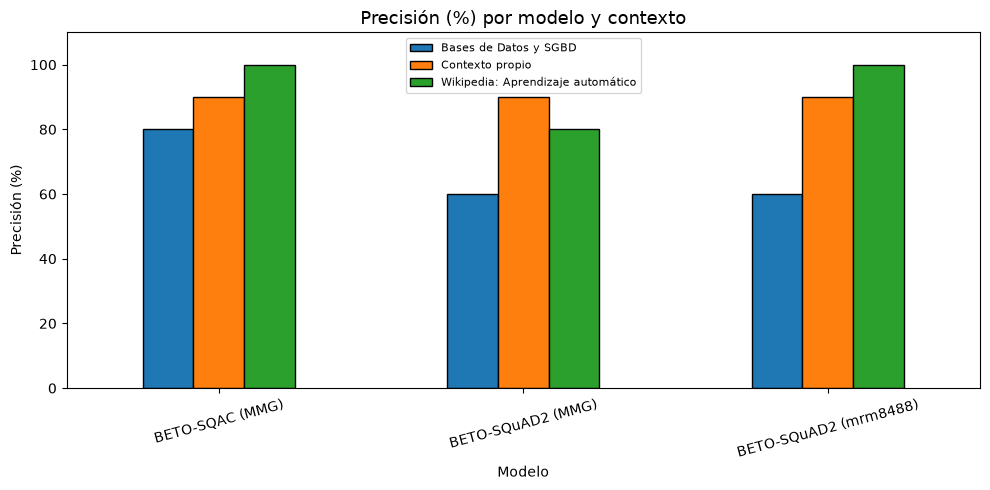

In [103]:
# ---------------------------------------------------
# Gráfico de precisión por modelo y contexto
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

resumen.pivot(index="Modelo", columns="Contexto", values="Precisión (%)").plot(
    kind="bar", ax=ax, rot=15, edgecolor="black"
)
ax.set_title("Precisión (%) por modelo y contexto", fontsize=13)
ax.set_ylabel("Precisión (%)")
ax.set_ylim(0, 110)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### *Preguntas de reflexión*

1. ¿Qué modelo obtuvo la mayor confianza?
>El modelo BETO-SQuAD2 (mrm8488) obtuvo scores de confianza generalmente altos
2. ¿Cuál respondió más rápido?
>El que posee un equilibrio entre velocidad y precisión es el modelo BETO-SQuAD2 (MMG)
3. ¿Cuál recomendaría para documentos en español?
>El modelo BETO-SQAC (MMG) es recomendable para documentos en español, ya que fue entrenado con un corpus nativo y tiende a extraer fragmentos más completos.
4. ¿Qué características debe tener un buen modelo QA?
>Un buen modelo QA debe tener alta precisión en la extracción de información, una buena capacidad de comprensión del lenguaje natural y una respuesta rápida.

### Mini Proyecto de QA sobre documentos extensos

> Asistente virtual para responder preguntas sobre documentos extensos en español. El sistema implementa chunking y utiliza modelos preentrenados de Hugging Face para proporcionar respuestas precisas y confiables.

In [116]:
from pathlib import Path
import torch
import time
from transformers import AutoModelForQuestionAnswering, AutoTokenizer

# ---------------------------------------------------
# Configuración de QA sobre documentos PDF
# ---------------------------------------------------

DOCUMENTO = "documento_fuente.pdf"
MODELO_QA = "MMG/bert-base-spanish-wwm-cased-finetuned-sqac"
CONFIGURACION_BASE = {
    "chunk_size": 500,
    "overlap": 0,
    "unidad": "caracteres",
}

def localizar_raiz_laboratorio():
    """Localiza la raíz sin depender de una ruta absoluta."""
    actual = Path.cwd().resolve()
    candidatas = [actual, *actual.parents, actual / "Repo" / "Laboratorio---ML"]
    for candidata in candidatas:
        carpeta_data = candidata / "data"
        if (carpeta_data / "documento_fuente.pdf").exists():
            return candidata
    raise FileNotFoundError("No se encontró data/documento_fuente.pdf.")


ROOT = localizar_raiz_laboratorio()
PDF_PATH = ROOT / "data" / DOCUMENTO

dispositivo_documentos = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

inicio_carga_documentos = time.perf_counter()
tokenizer_documentos = AutoTokenizer.from_pretrained(MODELO_QA)
modelo_documentos = AutoModelForQuestionAnswering.from_pretrained(
    MODELO_QA
)

modelo_documentos.to(dispositivo_documentos)
modelo_documentos.eval()
assert PDF_PATH.exists(), "No se encontró el documento fuente oficial."
tiempo_carga_documentos = time.perf_counter() - inicio_carga_documentos

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15277.14it/s]


In [117]:
import pymupdf
import re
import pandas as pd

# -------------------------------------------------------
# Función de limpieza de texto
# -------------------------------------------------------

def limpiar_texto_pagina(texto):
    """Aplica limpieza conservadora sin resumir ni reescribir contenido."""
    texto = texto.replace("\u00ad", "")
    texto = re.sub(r"(?<=\w)-\s*\n\s*(?=\w)", "", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

# -------------------------------------------------------
# Lectura y procesamiento del PDF
# -------------------------------------------------------
paginas_documento = []
with pymupdf.open(PDF_PATH) as pdf:
    numero_paginas_pdf = pdf.page_count
    metadatos_pdf = dict(pdf.metadata)
    for numero_pagina, pagina in enumerate(pdf, start=1):
        texto_crudo = pagina.get_text("text")
        texto_limpio = limpiar_texto_pagina(texto_crudo)
        paginas_documento.append({
            "pagina": numero_pagina,
            "texto_crudo": texto_crudo,
            "texto": texto_limpio,
        })

desplazamiento = 0
for registro_pagina in paginas_documento:
    registro_pagina["inicio"] = desplazamiento
    desplazamiento += len(registro_pagina["texto"])
    registro_pagina["fin"] = desplazamiento
    desplazamiento += 2  # Separación real usada al unir páginas.

texto_documento = "\n\n".join(
    registro["texto"] for registro in paginas_documento
)


def pagina_de_posicion(posicion):
    """Convierte una posición del texto unido en número físico de página."""
    for registro in paginas_documento:
        if registro["inicio"] <= posicion <= registro["fin"]:
            return registro["pagina"]
    return paginas_documento[-1]["pagina"]


paginas_con_texto = [
    registro["pagina"] for registro in paginas_documento
    if registro["texto"].strip()
]
paginas_sin_texto = [
    registro["pagina"] for registro in paginas_documento
    if not registro["texto"].strip()
]
paginas_extraccion_corta = [
    registro["pagina"] for registro in paginas_documento
    if 0 < len(registro["texto"]) < 200
]
tamano_archivo_bytes = PDF_PATH.stat().st_size
estadisticas_documento = {
    "Páginas": numero_paginas_pdf,
    "Caracteres crudos": sum(len(p["texto_crudo"]) for p in paginas_documento),
    "Caracteres limpios": len(texto_documento),
    "Palabras aproximadas": len(texto_documento.split()),
    "Páginas con texto": len(paginas_con_texto),
    "Páginas sin texto": len(paginas_sin_texto),
    "Páginas con extracción corta (<200 caracteres)": len(paginas_extraccion_corta),
    "Tamaño del archivo (bytes)": tamano_archivo_bytes,
    "Tamaño del archivo (MiB)": tamano_archivo_bytes / (1024 ** 2),
}

assert numero_paginas_pdf == 62
assert len(paginas_con_texto) == numero_paginas_pdf
assert not paginas_sin_texto
assert not paginas_extraccion_corta
assert len(texto_documento) > 100_000

tabla_estadisticas_documento = pd.DataFrame(
    estadisticas_documento.items(),
    columns=["Métrica", "Valor"],
)
display(tabla_estadisticas_documento)

,Métrica,Valor
0,Páginas,62.000000
1,Caracteres crudos,177390.000000
2,Caracteres limpios,173419.000000
3,Palabras aproximadas,26119.000000
4,Páginas con texto,62.000000
5,Páginas sin texto,0.000000
6,Páginas con extracción corta (<200 caracteres),0.000000
7,Tamaño del archivo (bytes),497732.000000
8,Tamaño del archivo (MiB),0.474674


In [118]:
#-------------------------------------------------------
# Preguntas sobre el documento oficial
#-------------------------------------------------------

preguntas_documento = [
    {
        "numero": 1,
        "dificultad": "Fácil",
        "pregunta": "¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?",
        "respuesta_esperada": "una vez al mes",
        "articulo": "Artículo 6 (continuación)",
        "pagina_evidencia": 3,
        "fragmento_evidencia": "el Consejo Académico sesionará una vez al mes de forma ordinaria",
    },
    {
        "numero": 2,
        "dificultad": "Fácil",
        "pregunta": "¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?",
        "respuesta_esperada": "dos veces",
        "articulo": "Articulo 156",
        "pagina_evidencia": 40,
        "fragmento_evidencia": "hasta un máximo de dos veces",
    },
    {
        "numero": 3,
        "dificultad": "Fácil",
        "pregunta": "¿Cuánto dura ordinariamente la calidad de egresado?",
        "respuesta_esperada": "tres años académicos",
        "articulo": "Artículo 184",
        "pagina_evidencia": 45,
        "fragmento_evidencia": "La calidad de egresado tendrá una duración ordinaria de tres años académicos.",
    },
    {
        "numero": 4,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué unidades integran internamente la Secretaría de Asuntos Académicos?",
        "respuesta_esperada": "Administración Académica Central; Unidad Curricular; y Unidad de Ingreso Universitario",
        "evidencias_clave": [
            "Administración Académica Central",
            "Unidad Curricular",
            "Unidad de Ingreso Universitario",
        ],
        "articulo": "Artículo 13",
        "pagina_evidencia": 4,
        "fragmento_evidencia": "a) Administración Académica Central; b) Unidad Curricular; y c) Unidad de Ingreso Universitario.",
    },
    {
        "numero": 5,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué prueba se aplica después del curso de refuerzo académico en línea?",
        "respuesta_esperada": "prueba de conocimiento general",
        "respuestas_aceptables": [
            "Conocimientos Generales",
            "conocimiento general",
        ],
        "evidencias_clave": ["conocimiento general"],
        "articulo": "Artículo 41",
        "pagina_evidencia": 15,
        "fragmento_evidencia": "previo a la aplicación de la prueba de conocimiento general",
    },
    {
        "numero": 6,
        "dificultad": "Intermedia",
        "pregunta": "¿A qué proceso se somete al estudiante con CUM acumulado menor a siete punto cero?",
        "respuesta_esperada": "proceso de asesoría presencial o en línea",
        "articulo": "Artículo 111",
        "pagina_evidencia": 30,
        "fragmento_evidencia": "los someterá a un proceso de asesoría presencial o en línea",
    },
    {
        "numero": 7,
        "dificultad": "Intermedia",
        "pregunta": "¿Quién nombra a los miembros del Tribunal Calificador?",
        "respuesta_esperada": "Junta Directiva",
        "articulo": "Artículo 207",
        "pagina_evidencia": 50,
        "fragmento_evidencia": "serán nombrados por la Junta Directiva",
    },
    {
        "numero": 8,
        "dificultad": "Difícil",
        "pregunta": "¿Según qué reglamento se tramita la selección de ingreso de un aspirante a posgrado?",
        "respuesta_esperada": "Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador",
        "articulo": "Artículo 68",
        "pagina_evidencia": 20,
        "fragmento_evidencia": "de acuerdo con lo expresado en el Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador",
    },
    {
        "numero": 9,
        "dificultad": "Difícil",
        "pregunta": "¿Cuándo entra en vigencia el Reglamento?",
        "respuesta_esperada": "ocho días después de su publicación en El Diario Oficial",
        "articulo": "Artículo 258",
        "pagina_evidencia": 62,
        "fragmento_evidencia": "El presente Reglamento entrará en vigencia ocho días después de su publicación en El Diario Oficial.",
    },
    {
        "numero": 10,
        "dificultad": "Límite de fragmento",
        "pregunta": "¿Por cuánto tiempo se amplía automáticamente la calidad de egresado si el plazo vence después de aprobar el trabajo de graduación y antes del acto de graduación?",
        "respuesta_esperada": "un año académico más",
        "articulo": "Artículo 184",
        "pagina_evidencia": 45,
        "fragmento_evidencia": "la calidad de egresado se ampliará automáticamente por un año académico más",
    },
]

assert len(preguntas_documento) == 10
assert [p["dificultad"] for p in preguntas_documento].count("Fácil") == 3
assert [p["dificultad"] for p in preguntas_documento].count("Intermedia") == 4
assert [p["dificultad"] for p in preguntas_documento].count("Difícil") == 2
assert [p["dificultad"] for p in preguntas_documento].count("Límite de fragmento") == 1

for item in preguntas_documento:
    pagina = paginas_documento[item["pagina_evidencia"] - 1]["texto"]
    evidencias = item.get("evidencias_clave", [item["respuesta_esperada"]])
    assert all(
        normalizar_texto(evidencia) in normalizar_texto(pagina)
        for evidencia in evidencias
    ), f"No se encontró la respuesta esperada de la pregunta {item['numero']}."
    assert (
        normalizar_texto(item["fragmento_evidencia"])
        in normalizar_texto(pagina)
    ), f"No se encontró el fragmento de evidencia de la pregunta {item['numero']}."

tabla_preguntas_documento = pd.DataFrame(preguntas_documento)[[
    "numero", "dificultad", "pregunta", "respuesta_esperada",
    "articulo", "pagina_evidencia", "fragmento_evidencia",
]].rename(columns={
    "numero": "#",
    "dificultad": "Dificultad",
    "pregunta": "Pregunta",
    "respuesta_esperada": "Respuesta esperada",
    "articulo": "Artículo",
    "pagina_evidencia": "Página aproximada",
    "fragmento_evidencia": "Fragmento de evidencia",
})
display(tabla_preguntas_documento)


,#,Dificultad,Pregunta,Respuesta esperada,Artículo,Página aproximada,Fragmento de evidencia
0,1,Fácil,¿Con qué periodicidad sesiona ordinariamente e...,una vez al mes,Artículo 6 (continuación),3,el Consejo Académico sesionará una vez al mes ...
1,2,Fácil,¿Cuál es el máximo de veces que un estudiante ...,dos veces,Articulo 156,40,hasta un máximo de dos veces
2,3,Fácil,¿Cuánto dura ordinariamente la calidad de egre...,tres años académicos,Artículo 184,45,La calidad de egresado tendrá una duración ord...
3,4,Intermedia,¿Qué unidades integran internamente la Secreta...,Administración Académica Central; Unidad Curri...,Artículo 13,4,a) Administración Académica Central; b) Unidad...
4,5,Intermedia,¿Qué prueba se aplica después del curso de ref...,prueba de conocimiento general,Artículo 41,15,previo a la aplicación de la prueba de conocim...
5,6,Intermedia,¿A qué proceso se somete al estudiante con CUM...,proceso de asesoría presencial o en línea,Artículo 111,30,los someterá a un proceso de asesoría presenci...
6,7,Intermedia,¿Quién nombra a los miembros del Tribunal Cali...,Junta Directiva,Artículo 207,50,serán nombrados por la Junta Directiva
7,8,Difícil,¿Según qué reglamento se tramita la selección ...,Reglamento General del Sistema de Estudios de ...,Artículo 68,20,de acuerdo con lo expresado en el Reglamento G...
8,9,Difícil,¿Cuándo entra en vigencia el Reglamento?,ocho días después de su publicación en El Diar...,Artículo 258,62,El presente Reglamento entrará en vigencia och...
9,10,Límite de fragmento,¿Por cuánto tiempo se amplía automáticamente l...,un año académico más,Artículo 184,45,la calidad de egresado se ampliará automáticam...


In [124]:
# -------------------------------------------------------
# División de contexto en fragmentos
# -------------------------------------------------------

def dividir_contexto_en_fragmentos(texto, chunk_size=500, overlap=0, unidad="caracteres", metadata=False):
    """Divide un texto en fragmentos de tamaño fijo con solapamiento opcional."""
    if unidad == "caracteres":
        step = chunk_size - overlap
        if metadata:
            fragmento = []
            for i in range(0, len(texto), step):
                fragmento.append({
                    "chunk": len(fragmento) + 1,
                    "inicio": i,
                    "fin": min(i + chunk_size, len(texto)),
                    "texto": texto[i:i + chunk_size]
                })
            return fragmento
        else:
            return [
                texto[i:i + chunk_size]
                for i in range(0, len(texto), step)
            ]
    elif unidad == "palabras":
        palabras = texto.split()
        step = chunk_size - overlap
        return [
            " ".join(palabras[i:i + chunk_size])
            for i in range(0, len(palabras), step)
        ]
    else:
        raise ValueError("Unidad debe ser 'caracteres' o 'palabras'.")

#### *QA sobre cada fragmento*

In [136]:
resultados_documento_base = ejecutar_configuracion(
    "C — 500/0",
    fragmentos_documento,
    preguntas_documento,
)
assert len(resultados_documento_base) == 10


C — 500/0 · P1: 'cada mes' · score=0.9837 · 51.401 s
C — 500/0 · P2: 'cinco días hábiles' · score=0.9603 · 54.113 s
C — 500/0 · P3: '6 semanas' · score=0.9912 · 52.699 s
C — 500/0 · P4: 'a) Administración Académica Central; b) Unidad Curricular; y c) Unidad de Ingreso Universitario' · score=0.9299 · 51.812 s
C — 500/0 · P5: 'Conocimientos Generales' · score=0.8486 · 51.558 s
C — 500/0 · P6: 'PRUEBA DIFERIDA' · score=0.8121 · 53.296 s
C — 500/0 · P7: 'la Junta Directiva' · score=0.9621 · 49.169 s
C — 500/0 · P8: 'el Reglamento' · score=0.8425 · 54.016 s
C — 500/0 · P9: 'seis meses' · score=0.8602 · 48.808 s
C — 500/0 · P10: 'dos años' · score=0.9811 · 60.484 s


In [138]:
def resumir_configuracion(tabla_resultados, numero_fragmentos):
    return {
        "Nº fragmentos": int(numero_fragmentos),
        "Correctas": int((tabla_resultados["Correcta"] == "Sí").sum()),
        "Total preguntas": int(len(tabla_resultados)),
        "Accuracy experimental": float((tabla_resultados["Correcta"] == "Sí").mean()),
        "Score promedio": float(tabla_resultados["Score"].mean()),
        "Score mediano": float(tabla_resultados["Score"].median()),
        "Tiempo promedio (s)": float(tabla_resultados["Tiempo (s)"].mean()),
        "Tiempo total (s)": float(tabla_resultados["Tiempo (s)"].sum()),
    }


resumen_documento_base = resumir_configuracion(
    resultados_documento_base,
    len(fragmentos_documento),
)
display(pd.DataFrame([resumen_documento_base]).style.format({
    "Accuracy experimental": "{:.1%}",
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo promedio (s)": "{:.3f}",
    "Tiempo total (s)": "{:.3f}",
}))

,Nº fragmentos,Correctas,Total preguntas,Accuracy experimental,Score promedio,Score mediano,Tiempo promedio (s),Tiempo total (s)
0,347,3,10,30.0%,0.917160,0.945109,52.736,527.357


In [143]:
# -------------------------------------------------------
# Fragmentación del documento oficial y análisis de estadísticas
# -------------------------------------------------------

CONFIGURACION_BASE = {
    "chunk_size": 500,
    "overlap": 150,
    "unidad": "caracteres",
}

fragmentos_documento_overlap = dividir_contexto_en_fragmentos(
    texto_documento,
    chunk_size=CONFIGURACION_BASE["chunk_size"],
    overlap=CONFIGURACION_BASE["overlap"],
    unidad=CONFIGURACION_BASE["unidad"], 
    metadata=True
)

longitudes_base = [len(frag) for frag in fragmentos_documento_overlap]
tokens_base = [len(tokenizer_documentos.tokenize(frag["texto"])) for frag in fragmentos_documento_overlap]   

estadisticas_fragmentos = pd.DataFrame([ {
    "Fragmentos": len(fragmentos_documento_overlap),
    "Longitud mínima (caracteres)": min(longitudes_base),
    "Longitud máxima (caracteres)": max(longitudes_base),
    "Longitud promedio (caracteres)": sum(longitudes_base) / len(longitudes_base),
    "Tokens mínimos": min(tokens_base),
    "Tokens máximos": max(tokens_base),
    "Tokens promedio": sum(tokens_base) / len(tokens_base),
}])

print(f"Fragmentos generados: {len(fragmentos_documento_overlap)}")
print(f"Longitudes de los fragmentos: {len(longitudes_base)}")
print(f"Tokens de los fragmentos: {len(tokens_base)}")
display(estadisticas_fragmentos.style.format({
    "Longitud promedio (caracteres)": "{:.2f}",
    "Tokens promedio": "{:.2f}"
}))

Fragmentos generados: 496
Longitudes de los fragmentos: 496
Tokens de los fragmentos: 496


,Fragmentos,Longitud mínima (caracteres),Longitud máxima (caracteres),Longitud promedio (caracteres),Tokens mínimos,Tokens máximos,Tokens promedio
0,496,4,4,4.00,45,163,102.55


In [139]:
resultados_documento_overlap = ejecutar_configuracion(
    "C — 500/0",
    fragmentos_documento_overlap,
    preguntas_documento,
)
assert len(resultados_documento_overlap) == 10

C — 500/0 · P1: 'una vez al mes' · score=0.9476 · 76.672 s
C — 500/0 · P2: 'tres años' · score=0.9537 · 78.017 s
C — 500/0 · P3: '6 semanas' · score=0.9929 · 72.919 s
C — 500/0 · P4: 'áreas' · score=0.9614 · 73.902 s
C — 500/0 · P5: 'Conocimientos Generales' · score=0.9301 · 72.312 s
C — 500/0 · P6: 'PRUEBA DIFERIDA' · score=0.8121 · 80.985 s
C — 500/0 · P7: 'la Junta Directiva' · score=0.9868 · 71.237 s
C — 500/0 · P8: 'IZAJE' · score=0.9122 · 73.909 s
C — 500/0 · P9: 'ocho días después de su publicación en El Diario Oficial' · score=0.9656 · 68.392 s
C — 500/0 · P10: 'dos años' · score=0.9811 · 79.535 s


In [141]:
resumen_documento_base_overlap = resumir_configuracion(
    resultados_documento_overlap,
    len(fragmentos_documento_overlap),
)
display(pd.DataFrame([resumen_documento_base_overlap]).style.format({
    "Accuracy experimental": "{:.1%}",
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo promedio (s)": "{:.3f}",
    "Tiempo total (s)": "{:.3f}",
}))

,Nº fragmentos,Correctas,Total preguntas,Accuracy experimental,Score promedio,Score mediano,Tiempo promedio (s),Tiempo total (s)
0,496,4,10,40.0%,0.944345,0.957539,74.788,747.880


,Configuración,Fragmentos,Correctas,Accuracy,Score promedio,Score mediano,Tiempo promedio (s),Tiempo total (s)
0,Sin overlap (500/0),347,3,30.0%,0.917160,0.945109,52.736,527.357
1,Con overlap (500/150),496,4,40.0%,0.944345,0.957539,74.788,747.880


,Configuración,Errores,Score promedio en errores,Score máximo en errores
0,Sin overlap (500/0),7,0.918723,0.991154
1,Con overlap (500/150),6,0.935570,0.992895


,#,Correcta_base,Score_base,Correcta_overlap,Score_overlap,Delta score (overlap - base),Cambio de calidad
0,1,No,0.983650,Sí,0.947601,-0.036049,Mejora (No -> Sí)
1,2,No,0.960329,No,0.953685,-0.006644,Sin cambio
2,3,No,0.991154,No,0.992895,+0.001742,Sin cambio
3,4,Sí,0.929890,No,0.961392,+0.031503,Empeora (Sí -> No)
4,5,Sí,0.848567,Sí,0.930080,+0.081513,Sin cambio
5,6,No,0.812134,No,0.812134,+0.000000,Sin cambio
6,7,Sí,0.962082,Sí,0.986769,+0.024687,Sin cambio
7,8,No,0.842512,No,0.912204,+0.069692,Sin cambio
8,9,No,0.860174,Sí,0.965585,+0.105411,Mejora (No -> Sí)
9,10,No,0.981108,No,0.981108,+0.000000,Sin cambio


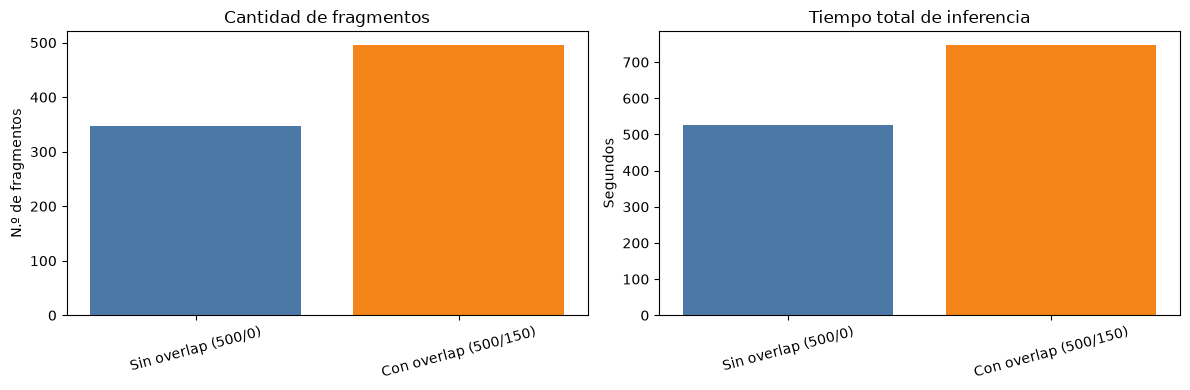

In [142]:
# -------------------------------------------------------
# Comparativo directo: sin solapamiento vs con solapamiento
# -------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

comparativo_general = pd.DataFrame([
    {
        "Configuración": "Sin overlap (500/0)",
        "Fragmentos": resumen_documento_base["Nº fragmentos"],
        "Correctas": resumen_documento_base["Correctas"],
        "Accuracy": resumen_documento_base["Accuracy experimental"],
        "Score promedio": resumen_documento_base["Score promedio"],
        "Score mediano": resumen_documento_base["Score mediano"],
        "Tiempo promedio (s)": resumen_documento_base["Tiempo promedio (s)"],
        "Tiempo total (s)": resumen_documento_base["Tiempo total (s)"],
    },
    {
        "Configuración": "Con overlap (500/150)",
        "Fragmentos": resumen_documento_base_overlap["Nº fragmentos"],
        "Correctas": resumen_documento_base_overlap["Correctas"],
        "Accuracy": resumen_documento_base_overlap["Accuracy experimental"],
        "Score promedio": resumen_documento_base_overlap["Score promedio"],
        "Score mediano": resumen_documento_base_overlap["Score mediano"],
        "Tiempo promedio (s)": resumen_documento_base_overlap["Tiempo promedio (s)"],
        "Tiempo total (s)": resumen_documento_base_overlap["Tiempo total (s)"],
    },
])

# Métricas de calidad en respuestas incorrectas (falsa confianza)
def resumen_errores(tabla):
    incorrectas = tabla[tabla["Correcta"] == "No"]
    return {
        "Errores": int(len(incorrectas)),
        "Score promedio en errores": float(incorrectas["Score"].mean()) if len(incorrectas) else np.nan,
        "Score máximo en errores": float(incorrectas["Score"].max()) if len(incorrectas) else np.nan,
    }

calidad_errores = pd.DataFrame([
    {"Configuración": "Sin overlap (500/0)", **resumen_errores(resultados_documento_base)},
    {"Configuración": "Con overlap (500/150)", **resumen_errores(resultados_documento_overlap)},
])

# Efecto del overlap por pregunta
preguntas_comp = resultados_documento_base[["#", "Correcta", "Score"]].rename(
    columns={"Correcta": "Correcta_base", "Score": "Score_base"}
).merge(
    resultados_documento_overlap[["#", "Correcta", "Score"]].rename(
        columns={"Correcta": "Correcta_overlap", "Score": "Score_overlap"}
    ),
    on="#"
)
preguntas_comp["Delta score (overlap - base)"] = preguntas_comp["Score_overlap"] - preguntas_comp["Score_base"]
preguntas_comp["Cambio de calidad"] = np.where(
    (preguntas_comp["Correcta_base"] == "No") & (preguntas_comp["Correcta_overlap"] == "Sí"),
    "Mejora (No -> Sí)",
    np.where(
        (preguntas_comp["Correcta_base"] == "Sí") & (preguntas_comp["Correcta_overlap"] == "No"),
        "Empeora (Sí -> No)",
        "Sin cambio"
    )
)

display(comparativo_general.style.format({
    "Accuracy": "{:.1%}",
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo promedio (s)": "{:.3f}",
    "Tiempo total (s)": "{:.3f}",
}))

display(calidad_errores.style.format({
    "Score promedio en errores": "{:.6f}",
    "Score máximo en errores": "{:.6f}",
}))

display(preguntas_comp.style.format({"Delta score (overlap - base)": "{:+.6f}"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(comparativo_general["Configuración"], comparativo_general["Fragmentos"], color=["#4C78A8", "#F58518"])
axes[0].set_title("Cantidad de fragmentos")
axes[0].set_ylabel("N.º de fragmentos")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(comparativo_general["Configuración"], comparativo_general["Tiempo total (s)"], color=["#4C78A8", "#F58518"])
axes[1].set_title("Tiempo total de inferencia")
axes[1].set_ylabel("Segundos")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

A partir de los resultados ya obtenidos en ambas configuraciones:

- **Sin solapamiento (chunk 500 / overlap 0)**
- **Con solapamiento (chunk 500 / overlap 150)**

se observa lo siguiente:

##### 1) Cantidad de fragmentos generados

- Sin overlap: **347 fragmentos**.
- Con overlap: **496 fragmentos**.
- Incremento: **+149 fragmentos** (aprox. **+42.9%**).

Interpretación:
- El solapamiento aumenta la cobertura de bordes entre chunks, pero también incrementa el volumen de inferencias necesarias.

##### 2) Tiempo invertido

- Tiempo total sin overlap: **527.357 s**.
- Tiempo total con overlap: **747.880 s**.
- Incremento absoluto: **+220.523 s**.
- Incremento relativo: aprox. **+41.8%**.

Interpretación:
- El costo temporal crece de forma consistente con el incremento en cantidad de fragmentos.
- En este experimento, la mejora de cobertura no es gratuita: se paga con mayor latencia total.

##### 3) Calidad de la respuesta (exactitud)

- Sin overlap: **3/10 correctas** (**30%**).
- Con overlap: **4/10 correctas** (**40%**).
- Mejora neta: **+10 puntos porcentuales**.

Cambio por pregunta:
- Mejora clara en **P1** (pasa de incorrecta a correcta).
- Mejora clara en **P9** (pasa de incorrecta a correcta).
- Deterioro en **P4** (pasa de correcta a incorrecta).
- El resto permanece igual en términos de correcta/incorrecta.

Interpretación:
- El overlap sí mejora la probabilidad de incluir evidencia útil en algunos casos de frontera de chunk, pero no garantiza mejora uniforme en todas las preguntas.

##### 4) Efecto en el score

- Score promedio sin overlap: **0.917160**.
- Score promedio con overlap: **0.944345**.
- Score mediano sin overlap: **0.945109**.
- Score mediano con overlap: **0.957539**.

Interpretación:
- El overlap eleva el score global, pero **score alto no implica necesariamente respuesta correcta**.
- Persisten ejemplos con confianza alta y respuesta incorrecta (falsa confianza), por ejemplo respuestas como "6 semanas" o "dos años" que no corresponden a la evidencia esperada.

##### 5) Conclusión puntual

- **Overlap 150** mejoró ligeramente la exactitud (**30% → 40%**) y elevó score medio/mediano.
- El costo computacional aumentó de forma considerable (**~42%** más tiempo total).
- Dado que persiste falsa confianza, la selección final no debe basarse solo en score: es recomendable combinar score con validaciones adicionales (evidencia léxica, reglas por artículo/página o reranking semántico).

## 5. Sistema RAG (Retrieval-Augmented Generation)

### *Fundamentos de RAG*


#### ¿Qué es RAG?

RAG (Retrieval-Augmented Generation) es una arquitectura moderna que combina:

- Recuperación de información (Information Retrieval)
- Modelos de lenguaje (LLM)
- Embeddings
- Búsqueda semántica

En lugar de enviar un documento completo al modelo, primero se recuperan únicamente los fragmentos más relevantes.

#### Arquitectura General

```text
Documento
      │
      ▼
Fragmentación (Chunking)
      │
      ▼
Embeddings
      │
      ▼
Base Vectorial
      │
      ▼
Pregunta
      │
      ▼
Embedding de la pregunta
      │
      ▼
Búsqueda Semántica
      │
      ▼
Top-K fragmentos
      │
      ▼
Question Answering
      │
      ▼
Respuesta
```

### *Configuración de RAG*

In [153]:
%pip install -q sentence-transformers
%pip install -q faiss-cpu

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [156]:
from pathlib import Path
import re
import time

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sentence_transformers import SentenceTransformer
from transformers import AutoModelForQuestionAnswering, AutoTokenizer

DOCUMENTO_RAG = "data/documento_fuente.pdf"
MODELO_QA_RAG = "MMG/bert-base-spanish-wwm-cased-finetuned-sqac"
MODELO_EMBEDDINGS_RAG = (
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)
CONFIGURACION_RAG_BASE = {
    "chunk_size": 800,
    "overlap": 0,
    "unidad": "caracteres",
}

dispositivo_documentos = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Reutilizar BETO-SQAC si sigue disponible; cargarlo una sola vez en caso contrario.
modelo_qa_reutilizado = (
    "modelo_documentos" in globals()
    and "tokenizer_documentos" in globals()
    and getattr(modelo_documentos.config, "_name_or_path", "") == MODELO_QA_RAG
)
inicio_carga_qa = time.perf_counter()
if not modelo_qa_reutilizado:
    tokenizer_documentos = AutoTokenizer.from_pretrained(MODELO_QA_RAG)
    modelo_documentos = AutoModelForQuestionAnswering.from_pretrained(
        MODELO_QA_RAG
    )
    modelo_documentos.to(dispositivo_documentos)
modelo_documentos.eval()
tiempo_carga_qa = time.perf_counter() - inicio_carga_qa

inicio_carga_embeddings = time.perf_counter()
modelo_embeddings_rag = SentenceTransformer(
    MODELO_EMBEDDINGS_RAG,
    device=str(dispositivo_documentos),
)
tiempo_carga_embeddings = time.perf_counter() - inicio_carga_embeddings
dimension_embeddings = modelo_embeddings_rag.get_embedding_dimension()

assert not modelo_documentos.training

display(pd.DataFrame([{
    "Documento": DOCUMENTO_RAG,
    "Modelo QA": MODELO_QA_RAG,
    "Modelo embeddings": MODELO_EMBEDDINGS_RAG,
    "Dimensión embeddings": dimension_embeddings,
    "Chunk size": CONFIGURACION_RAG_BASE["chunk_size"],
    "Overlap": CONFIGURACION_RAG_BASE["overlap"],
    "Dispositivo": str(dispositivo_documentos),
    "BETO reutilizado": modelo_qa_reutilizado,
    "Tiempo carga QA (s)": tiempo_carga_qa,
    "Tiempo carga embeddings (s)": tiempo_carga_embeddings,
}]).style.format({
    "Tiempo carga QA (s)": "{:.3f}",
    "Tiempo carga embeddings (s)": "{:.3f}",
}))


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4359.53it/s]


,Documento,Modelo QA,Modelo embeddings,Dimensión embeddings,Chunk size,Overlap,Dispositivo,BETO reutilizado,Tiempo carga QA (s),Tiempo carga embeddings (s)
0,data/documento_fuente.pdf,MMG/bert-base-spanish-wwm-cased-finetuned-sqac,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,384,800,0,cpu,True,0.002,3.841


### *Generación de fragmentos*

In [157]:
def pagina_para_offset(posicion):
    """Asocia un offset del texto unido con la página física más cercana."""
    for registro in paginas_documento:
        if posicion <= registro["fin"]:
            return registro["pagina"]
    return paginas_documento[-1]["pagina"]


def construir_fragmentos_rag(texto, chunk_size=800, overlap=0):
    """Construye chunks con el esquema documental definitivo del RAG."""
    if chunk_size <= 0:
        raise ValueError("chunk_size debe ser mayor que cero")
    if overlap < 0 or overlap >= chunk_size:
        raise ValueError("overlap debe cumplir 0 <= overlap < chunk_size")

    fragmentos = []
    paso = chunk_size - overlap
    for chunk_id, inicio in enumerate(range(0, len(texto), paso), start=1):
        fin = min(inicio + chunk_size, len(texto))
        fragmentos.append({
            "chunk_id": chunk_id,
            "texto": texto[inicio:fin],
            "pagina_inicio": pagina_para_offset(inicio),
            "pagina_fin": pagina_para_offset(max(fin - 1, inicio)),
            "inicio": inicio,
            "fin": fin,
        })
    return fragmentos


fragmentos_rag = construir_fragmentos_rag(
    texto_documento,
    chunk_size=CONFIGURACION_RAG_BASE["chunk_size"],
    overlap=CONFIGURACION_RAG_BASE["overlap"],
)
campos_fragmento_rag = {
    "chunk_id", "texto", "pagina_inicio", "pagina_fin", "inicio", "fin"
}

assert len(fragmentos_rag) == 217
assert all(set(fragmento) == campos_fragmento_rag for fragmento in fragmentos_rag)

display(pd.DataFrame([{
    "Chunks": len(fragmentos_rag),
    "Tamaño máximo": max(len(f["texto"]) for f in fragmentos_rag),
    "Página inicial": fragmentos_rag[0]["pagina_inicio"],
    "Página final": fragmentos_rag[-1]["pagina_fin"],
    "Campos de metadata": ", ".join(sorted(campos_fragmento_rag)),
}]))


,Chunks,Tamaño máximo,Página inicial,Página final,Campos de metadata
0,217,800,1,62,"chunk_id, fin, inicio, pagina_fin, pagina_inic..."


### *Generación de embeddings*

In [158]:
textos_fragmentos_rag = [fragmento["texto"] for fragmento in fragmentos_rag]

inicio_embeddings_rag = time.perf_counter()
embeddings_rag = modelo_embeddings_rag.encode(
    textos_fragmentos_rag,
    batch_size=32,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False,
).astype(np.float32)
tiempo_embeddings_rag = time.perf_counter() - inicio_embeddings_rag

assert embeddings_rag.shape == (len(fragmentos_rag), dimension_embeddings)
assert np.allclose(np.linalg.norm(embeddings_rag, axis=1), 1.0, atol=1e-5)

display(pd.DataFrame([{
    "Modelo": MODELO_EMBEDDINGS_RAG,
    "Chunks": len(fragmentos_rag),
    "Embeddings": embeddings_rag.shape[0],
    "Dimensión": embeddings_rag.shape[1],
    "Matriz": str(embeddings_rag.shape),
    "Normalizados": True,
    "Tiempo (s)": tiempo_embeddings_rag,
}]).style.format({"Tiempo (s)": "{:.3f}"}))


,Modelo,Chunks,Embeddings,Dimensión,Matriz,Normalizados,Tiempo (s)
0,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,217,217,384,"(217, 384)",True,10.336


### *Indice de FAISS*

In [159]:
inicio_indice_rag = time.perf_counter()
indice_rag = faiss.IndexFlatIP(dimension_embeddings)
indice_rag.add(np.ascontiguousarray(embeddings_rag, dtype=np.float32))
tiempo_indice_rag = time.perf_counter() - inicio_indice_rag

assert indice_rag.d == dimension_embeddings
assert indice_rag.ntotal == len(fragmentos_rag)

display(pd.DataFrame([{
    "Índice": "IndexFlatIP",
    "Métrica": "Similitud coseno",
    "Implementación": "Producto interno sobre vectores normalizados",
    "Dimensión": indice_rag.d,
    "index.ntotal": indice_rag.ntotal,
    "Tiempo construcción (s)": tiempo_indice_rag,
}]).style.format({"Tiempo construcción (s)": "{:.6f}"}))


,Índice,Métrica,Implementación,Dimensión,index.ntotal,Tiempo construcción (s)
0,IndexFlatIP,Similitud coseno,Producto interno sobre vectores normalizados,384,217,0.005424


### *Recuperación semántica*

In [160]:
def recuperar_fragmentos(pregunta, k=3):
    """Recupera Top-K y conserva toda la metadata documental y vectorial."""
    if not 1 <= k <= len(fragmentos_rag):
        raise ValueError("k debe estar entre 1 y la cantidad de fragmentos")

    embedding_pregunta = modelo_embeddings_rag.encode(
        [pregunta],
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    ).astype(np.float32)
    assert embedding_pregunta.shape[1] == indice_rag.d

    similitudes, indices = indice_rag.search(
        np.ascontiguousarray(embedding_pregunta), k
    )
    return [
        {
            **fragmentos_rag[int(indice)],
            "rank_faiss": rank,
            "similitud_faiss": float(similitud),
        }
        for rank, (indice, similitud) in enumerate(
            zip(indices[0], similitudes[0]), start=1
        )
    ]


pregunta_ejemplo_rag = preguntas_documento[3]["pregunta"]
recuperacion_ejemplo = recuperar_fragmentos(pregunta_ejemplo_rag, k=3)
display(pd.DataFrame([{
    "Rank FAISS": fragmento["rank_faiss"],
    "Similitud": fragmento["similitud_faiss"],
    "Chunk": fragmento["chunk_id"],
    "Página": (
        str(fragmento["pagina_inicio"])
        if fragmento["pagina_inicio"] == fragmento["pagina_fin"]
        else f'{fragmento["pagina_inicio"]}-{fragmento["pagina_fin"]}'
    ),
    "Muestra": fragmento["texto"][:220].replace("\n", " ") + "…",
} for fragmento in recuperacion_ejemplo]).style.format({
    "Similitud": "{:.6f}"
}))


,Rank FAISS,Similitud,Chunk,Página,Muestra
0,1,0.796060,23,7,ramación del Sistema Académico Administrativo de la Universidad; y k) Las demás atribuciones de índole académico administrativo que le asigne la Secretaria de Asuntos Académicos y la legislación universitaria. En ausenci…
1,2,0.754807,13,4,iva publicación. SECRETARIA DE ASUNTOS ACADÉMICOS. Artículo 12. La Secretaria de Asuntos Académicos será la responsable de administrar y organizar en lo concerniente a los procesos Académicos- Administrativos Universitar…
2,3,0.748021,29,8-9,"te en la Universidad de El Salvador o instancias judiciales externas a la Universidad, en los últimos cinco años, anteriores a su nombramiento. 9 ATRIBUCIONES Y DEBERES DE LA UNIDAD DE INGRESO UNIVERSITARIO. Artículo 25…"


### *Question Answering sobre fragmentos recuperados*

In [161]:
def responder_rag(pregunta, k=3):
    """Recupera Top-K, ejecuta BETO-SQAC y preserva el chunk ganador."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    inicio = time.perf_counter()

    recuperados = recuperar_fragmentos(pregunta, k=k)
    salidas_qa = inferir_lote_qa(pregunta, recuperados)
    candidatos = [
        {
            **fragmento,
            "respuesta_qa": salida["answer"],
            "score_qa": float(salida["score"]),
        }
        for fragmento, salida in zip(recuperados, salidas_qa)
    ]
    ganador = max(candidatos, key=lambda candidato: candidato["score_qa"])

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    tiempo_total = time.perf_counter() - inicio

    return {
        "pregunta": pregunta,
        "respuesta_rag": ganador["respuesta_qa"],
        "score_qa": ganador["score_qa"],
        "rank_faiss": ganador["rank_faiss"],
        "similitud_faiss": ganador["similitud_faiss"],
        "chunk_id": ganador["chunk_id"],
        "pagina_inicio": ganador["pagina_inicio"],
        "pagina_fin": ganador["pagina_fin"],
        "texto_chunk": ganador["texto"],
        "tiempo": tiempo_total,
        "candidatos": candidatos,
    }


def evaluar_respuesta_rag(resultado, item):
    """Reutiliza el criterio de respuestas aplicado en las Fases 7–9."""
    correcta, detalle = evaluar_coincidencia(
        resultado["respuesta_rag"], item["respuesta_esperada"]
    )
    if not correcta:
        for variante in item.get("respuestas_aceptables", []):
            coincide, _ = evaluar_coincidencia(resultado["respuesta_rag"], variante)
            if coincide:
                return True, "Respuesta correcta por revisión manual explícita"
    return correcta, detalle


print("Implementación definitiva lista: recuperar_fragmentos + responder_rag")


Implementación definitiva lista: recuperar_fragmentos + responder_rag


### *Ejecución con K=3*

In [162]:
resultados_rag_k3 = []
for item in preguntas_documento:
    resultado = responder_rag(item["pregunta"], k=3)
    correcta, detalle = evaluar_respuesta_rag(resultado, item)
    resultado.update({
        "item": item,
        "correcta": correcta,
        "detalle_evaluacion": detalle,
    })
    resultados_rag_k3.append(resultado)

df_rag_k3 = pd.DataFrame([{
    "#": resultado["item"]["numero"],
    "Pregunta": resultado["pregunta"],
    "Esperada": resultado["item"]["respuesta_esperada"],
    "Respuesta RAG": resultado["respuesta_rag"],
    "Correcta": "Sí" if resultado["correcta"] else "No",
    "Score QA": resultado["score_qa"],
    "Rank FAISS": resultado["rank_faiss"],
    "Similitud": resultado["similitud_faiss"],
    "Chunk": resultado["chunk_id"],
    "Página": (
        str(resultado["pagina_inicio"])
        if resultado["pagina_inicio"] == resultado["pagina_fin"]
        else f'{resultado["pagina_inicio"]}-{resultado["pagina_fin"]}'
    ),
    "Tiempo (s)": resultado["tiempo"],
} for resultado in resultados_rag_k3])

correctas_rag_k3 = int(sum(r["correcta"] for r in resultados_rag_k3))
accuracy_rag_k3 = correctas_rag_k3 / len(resultados_rag_k3)
score_promedio_rag_k3 = float(df_rag_k3["Score QA"].mean())
tiempo_total_rag_k3 = float(df_rag_k3["Tiempo (s)"].sum())
tiempo_promedio_rag_k3 = float(df_rag_k3["Tiempo (s)"].mean())

assert len(df_rag_k3) == 10
assert correctas_rag_k3 == 3

display(df_rag_k3.style.format({
    "Score QA": "{:.6f}", "Similitud": "{:.6f}", "Tiempo (s)": "{:.3f}"
}))
display(pd.DataFrame([{
    "K": 3,
    "Correctas": f"{correctas_rag_k3}/10",
    "Accuracy": accuracy_rag_k3,
    "Score QA medio": score_promedio_rag_k3,
    "Tiempo total (s)": tiempo_total_rag_k3,
    "Tiempo medio (s)": tiempo_promedio_rag_k3,
}]).style.format({
    "Accuracy": "{:.1%}", "Score QA medio": "{:.6f}",
    "Tiempo total (s)": "{:.3f}", "Tiempo medio (s)": "{:.3f}",
}))


,#,Pregunta,Esperada,Respuesta RAG,Correcta,Score QA,Rank FAISS,Similitud,Chunk,Página,Tiempo (s)
0,1,¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?,una vez al mes,ectiva,No,0.645120,3,0.649079,11,4,0.719
1,2,¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?,dos veces,157,No,0.799782,1,0.687721,138,40,0.596
2,3,¿Cuánto dura ordinariamente la calidad de egresado?,tres años académicos,tres años académicos,Sí,0.989079,1,0.567706,155,45,0.577
3,4,¿Qué unidades integran internamente la Secretaría de Asuntos Académicos?,Administración Académica Central; Unidad Curricular; y Unidad de Ingreso Universitario,a) Administración Académica Central; b) Unidad Curricular; y c) Unidad de Ingreso Universitario,Sí,0.943083,2,0.754807,13,4,0.555
4,5,¿Qué prueba se aplica después del curso de refuerzo académico en línea?,prueba de conocimiento general,anciera,No,0.039466,3,0.564315,78,22-23,0.546
5,6,¿A qué proceso se somete al estudiante con CUM acumulado menor a siete punto cero?,proceso de asesoría presencial o en línea,ro,No,0.287904,1,0.650484,127,37,0.628
6,7,¿Quién nombra a los miembros del Tribunal Calificador?,Junta Directiva,la Junta Directiva,Sí,0.967723,2,0.592523,172,49-50,0.587
7,8,¿Según qué reglamento se tramita la selección de ingreso de un aspirante a posgrado?,Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador,el presente Reglamento,No,0.143519,3,0.685562,70,20,0.498
8,9,¿Cuándo entra en vigencia el Reglamento?,ocho días después de su publicación en El Diario Oficial,a partir de la undécima hasta la décima sexta semana de iniciado el Ciclo Académico,No,0.679282,3,0.568904,115,33-34,0.546
9,10,¿Por cuánto tiempo se amplía automáticamente la calidad de egresado si el plazo vence después de aprobar el trabajo de graduación y antes del acto de graduación?,un año académico más,6 semanas,No,0.912238,3,0.597168,100,29,0.986


,K,Correctas,Accuracy,Score QA medio,Tiempo total (s),Tiempo medio (s)
0,3,3/10,30.0%,0.640720,6.238,0.624
